**Dataset:** `data/titanic.csv` (891 passengers). The placement columns of the original notebook are mapped to Titanic columns as described below.

Mapping: target `PlacementStatus` → `Survived`.

# Binary Logistic Regression — Survived

## Objective
Develop a Logistic Regression classification model to predict **`Survived`** and evaluate it using standard classification metrics.

### Data assumption
The data is already preprocessed:
- `X_train` = 80% preprocessed features
- `X_test` = 20% preprocessed features
- `y_train` = target for training
- `y_test` = target for testing

**No additional imputation, encoding, or scaling is performed here.**

### Required outputs
- `evaluate_classifier()` function
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report
- Coefficient bar chart


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)


## 2. Load Already-Preprocessed Data

In [2]:
# Change these paths to your actual files
X_TRAIN_PATH = "/Users/divyasaisomana/placement prediction system/data/titanic_X_train_processed.csv"
X_TEST_PATH  = "/Users/divyasaisomana/placement prediction system/data/titanic_X_test_processed.csv"
Y_TRAIN_PATH = "/Users/divyasaisomana/placement prediction system/data/titanic_y_train.csv"
Y_TEST_PATH  = "/Users/divyasaisomana/placement prediction system/data/titanic_y_test.csv"

X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH)
y_test = pd.read_csv(Y_TEST_PATH)

if isinstance(y_train, pd.DataFrame) and y_train.shape[1] == 1:
    y_train = y_train.iloc[:, 0]
if isinstance(y_test, pd.DataFrame) and y_test.shape[1] == 1:
    y_test = y_test.iloc[:, 0]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTarget distribution:")
print(y_train.value_counts().sort_index())


X_train: (712, 8)
X_test : (179, 8)
y_train: (712,)
y_test : (179,)

Target distribution:
Survived
0    439
1    273
Name: count, dtype: int64


## 3. Verify Preprocessed Data

In [3]:
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test :", X_test.isna().sum().sum())

print("\nFeature columns:")
print(list(X_train.columns))

print("\nTarget classes:")
print(sorted(pd.Series(y_train).unique()))


Missing values in X_train: 0
Missing values in X_test : 0

Feature columns:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

Target classes:
[np.int64(0), np.int64(1)]


## 4. Train Binary Logistic Regression

In [4]:
model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully.")
print("Classes:", model.classes_)


Model trained successfully.
Classes: [0 1]


## 5. Define `evaluate_classifier()`

In [5]:
def evaluate_classifier(model, X, y, dataset_name="Dataset"):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)

    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_prob)

    print(f"===== {dataset_name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc
    }


## 6. Evaluate Training and Test Performance

In [6]:
train_results = evaluate_classifier(
    model, X_train, y_train, "Training"
)

test_results = evaluate_classifier(
    model, X_test, y_test, "Test"
)

evaluation_df = pd.DataFrame([
    train_results,
    test_results
])

display(evaluation_df)


===== Training =====
Accuracy : 0.8076
Precision: 0.7698
Recall   : 0.7106
F1-score : 0.7390
ROC-AUC  : 0.8594

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       439
           1       0.77      0.71      0.74       273

    accuracy                           0.81       712
   macro avg       0.80      0.79      0.79       712
weighted avg       0.81      0.81      0.81       712

Confusion Matrix:
[[381  58]
 [ 79 194]]
===== Test =====
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-score : 0.7244
ROC-AUC  : 0.8436

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
[[98 12]
 [23 46]]


,Dataset,Accuracy,Precision,Recall,F1,ROC_AUC
0,Training,0.807584,0.769841,0.710623,0.739048,0.859412
1,Test,0.804469,0.793103,0.666667,0.724409,0.843610


## 7. Test Confusion Matrix

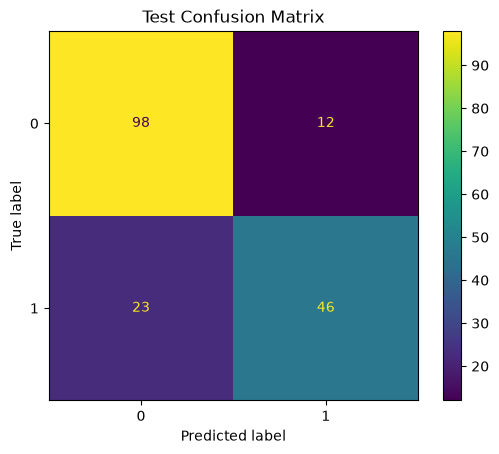

In [7]:
y_test_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    values_format="d"
)

plt.title("Test Confusion Matrix")
plt.show()


## 8. Coefficients

In [8]:
# Binary: one coefficient per feature.
# Multinomial: one coefficient row per class.

if model.coef_.shape[0] == 1:
    coefficient_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": model.coef_[0]
    })
    display(coefficient_df)

else:
    coefficient_df = pd.DataFrame(
        model.coef_,
        index=[f"Class={c}" for c in model.classes_],
        columns=X_train.columns
    )
    display(coefficient_df)


,Feature,Coefficient
0,Pclass,-1.090753
1,Age,-0.498480
2,SibSp,-0.257888
3,Parch,-0.060134
4,Fare,0.105412
5,Sex_male,-2.557094
6,Embarked_Q,0.284411
7,Embarked_S,-0.384515


## 9. Coefficient Bar Chart

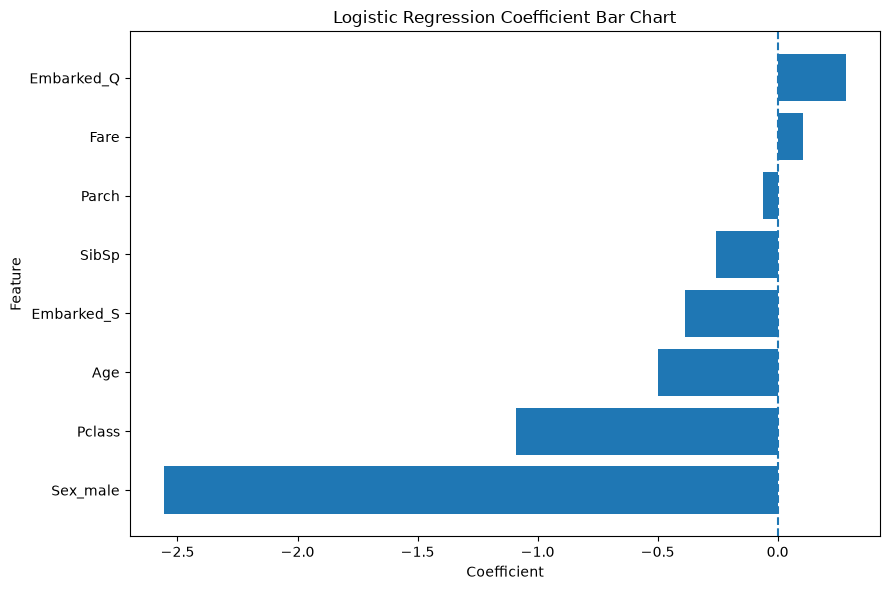

In [9]:
if model.coef_.shape[0] == 1:

    plot_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": model.coef_[0]
    }).sort_values("Coefficient")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["Feature"], plot_df["Coefficient"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title("Logistic Regression Coefficient Bar Chart")
    plt.tight_layout()
    plt.show()

else:
    coefficient_plot_df = coefficient_df.T

    ax = coefficient_plot_df.plot(
        kind="bar",
        figsize=(11, 6)
    )

    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Coefficient")
    ax.set_title("Multinomial Logistic Regression Coefficient Bar Chart")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Interpretation and Conclusion

### Target
This notebook predicts **`Survived`**.

### Metrics
- Accuracy: overall percentage of correct predictions.
- Precision: correctness of positive predictions.
- Recall: ability to identify actual positive cases.
- F1-score: balance between precision and recall.
- ROC-AUC: used for the binary model to measure discrimination across thresholds.

### Coefficients
A positive coefficient increases the model's tendency toward the corresponding class; a negative coefficient decreases it, subject to the preprocessing and class formulation.

### Final evaluation
The **test-set metrics** are the final performance results because `X_test` and `y_test` are kept separate from model fitting.
